# Stage B validation — robustness + stress (§8.2.4 + §8.2.5)

Diagnostics that grade *how* the RF behaves, not just *whether* it scores well:
- **§8.2.4 robustness** — feature importances (do physically sensible predictors dominate?), AOD-binned residual envelope (does bias structure look like a classic MODIS-style low-bias-at-high-AOD?), and **CAMS prior bias attribution** (is the RF residual bias inherited from the CAMS background, or generated by the RF itself?).
- **§8.2.5 cloud-period recovery** — stress test against long occlusions.  Does the model invent plausible-but-wrong fills during multi-day cloud blackouts?

In [3]:
from datetime import date
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import validate as vb
import config as cfg

START = cfg.TEST_START
END   = cfg.TEST_END
print(f'Held-out window: {START} → {END}')

Held-out window: 2025-01-01 → 2026-04-30


## §8.2.4a — Variable importance

Gini importances from the trained RF, normalised to percentages.  Sanity check: physically reasonable features (CAMS AOD, neighbour stats, time-of-day) should dominate.

In [4]:
vi = vb.variable_importance("rf_residual_stctx_tau6")
vi

,feature,gini_importance,pct_importance
0,obs_aod_mean_5x5,0.381478,38.147845
1,cams_aod,0.233661,23.366071
2,persistence_decay,0.112832,11.283154
3,cams_aod_lag_3h,0.090926,9.092637
4,month_sin,0.073474,7.347381
5,obs_aod_count_5x5,0.011429,1.142873
6,t2m,0.010005,1.000538
7,tcc,0.008130,0.812978
8,dpt,0.006991,0.699137
9,tcwv,0.005681,0.568075


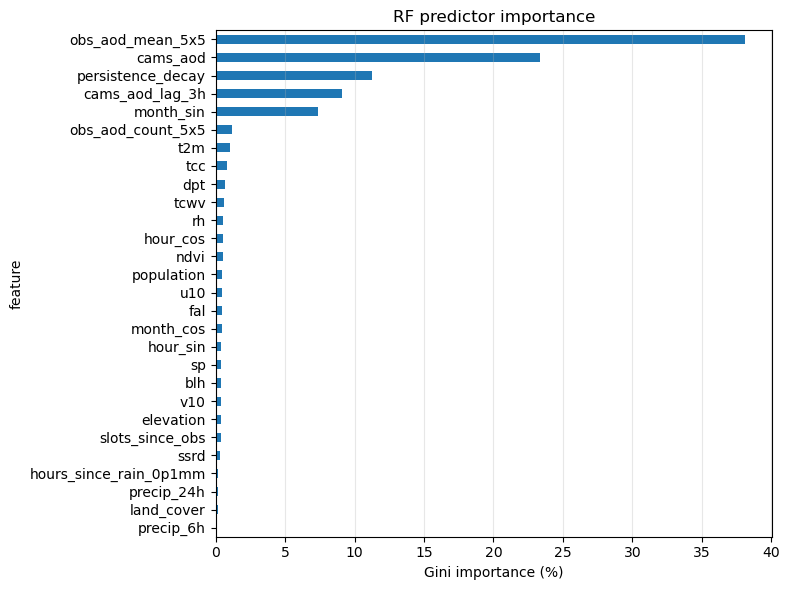

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
vi.iloc[::-1].plot.barh(x='feature', y='pct_importance', ax=ax, legend=False)
ax.set_xlabel('Gini importance (%)'); ax.set_title('RF predictor importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

## §8.2.4b — Residual envelope vs AERONET AOD

Bins residuals (`sat − AERONET`) by AERONET AOD (0.1 width) and reports `n / bias / sigma` per bin.  Reveals AOD-dependent bias structure (Lee 2025 Fig. 7 analogue).

In [6]:
pairs_rf = vb.aeronet_pairs(START, END, candidate='rf', blind_only=True)
env = vb.residual_envelope(pairs_rf)
env

,aer_bin,n,bias,sigma
0,0.0,69,0.285930,0.114367
1,0.1,197,0.244048,0.157125
2,0.2,137,0.169527,0.157430
3,0.3,88,0.083480,0.152806
4,0.4,33,-0.008647,0.158318
5,0.5,26,-0.094429,0.223911
6,0.6,16,-0.061275,0.265054
7,0.7,10,0.024313,0.159307
8,0.8,15,-0.247086,0.198712
9,0.9,13,-0.207347,0.234759


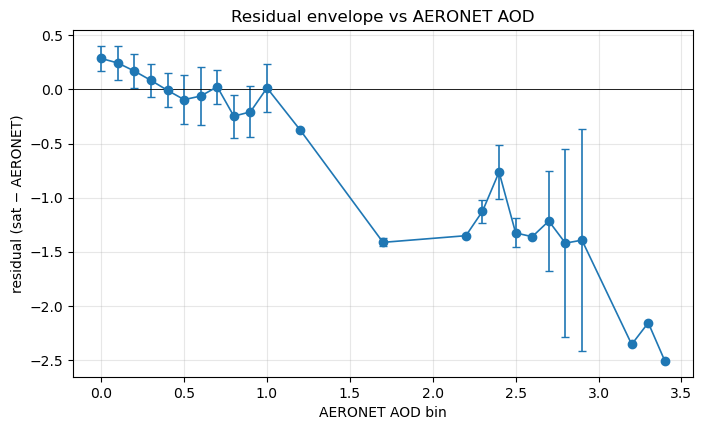

In [7]:
if not env.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.errorbar(env['aer_bin'], env['bias'], yerr=env['sigma'],
                fmt='o-', capsize=3, lw=1.2)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xlabel('AERONET AOD bin'); ax.set_ylabel('residual (sat − AERONET)')
    ax.set_title('Residual envelope vs AERONET AOD')
    ax.grid(alpha=0.3)

## §8.2.4c — CAMS prior bias attribution

The RF is trained on the residual `aod_minus_cams` ([config.py:160](config.py#L160)), so its output is `cams_aod + RF_residual_prediction`. Any systematic CAMS bias at a station propagates to the gap-fill unless the residual training saw enough local examples to push back.

If `cams_aod − AERONET` is already, say, +0.14 at Bac Lieu in the wet season, the residual-mode RF was **never** going to fix it — fixing it would require predicting a negative residual exactly when the regional training signal says the residual should be near zero.

This diagnostic decomposes the §8.2.4b envelope into two pieces on the same blind pairs:
- **CAMS bias** = `cams_aod − aer_aod` (the prior the RF stands on)
- **RF residual** = `rf_aod − cams_aod` (what the RF actually contributed)
- **Total** = `rf_aod − aer_aod` (what the user sees, == §8.2.4b)

If `Total ≈ CAMS bias` per (site, season), the RF is faithfully tracking CAMS and the bias is inherited — re-training won't help, swapping the prior or adding local correction will.

In [8]:
import ancillary as anc
from validate import _site_rc

# Re-use the same blind pairs as §8.2.4b (pairs_rf) — no new I/O loop over slots,
# we just open each unique CAMS slot once and sample the station pixel.
site_rcs = {s: _site_rc(s) for s in pairs_rf['site'].unique()}

cams_vals = []
cams_cache: dict = {}
for slot_utc, site in pairs_rf[['slot_utc', 'site']].itertuples(index=False):
    grid = cams_cache.get(slot_utc)
    if grid is None:
        grid = anc.cams_aod_slot(slot_utc.to_pydatetime() if hasattr(slot_utc, 'to_pydatetime') else slot_utc)
        cams_cache[slot_utc] = grid
    if grid is None:
        cams_vals.append(np.nan)
        continue
    r, c = site_rcs[site]
    v = grid[r, c]
    cams_vals.append(float(v) if np.isfinite(v) else np.nan)

attr = pairs_rf[['slot_utc', 'site', 'season', 'aer_aod', 'sat_aod']].copy()
attr = attr.rename(columns={'sat_aod': 'rf_aod'})
attr['cams_aod']     = cams_vals
attr['cams_minus_aer'] = attr['cams_aod'] - attr['aer_aod']   # CAMS prior bias
attr['rf_residual']    = attr['rf_aod']   - attr['cams_aod']  # what RF added
attr['total_bias']     = attr['rf_aod']   - attr['aer_aod']   # == §8.2.4b residual

attr = attr.dropna(subset=['cams_aod'])
print(f'attributed pairs: {len(attr)}  (of {len(pairs_rf)} blind RF pairs)')
attr.head()

/home/work1/miniconda3/envs/Airqua_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


attributed pairs: 636  (of 636 blind RF pairs)


,slot_utc,site,season,aer_aod,rf_aod,cams_aod,cams_minus_aer,rf_residual,total_bias
0,2025-01-02 06:30:00,Bac_Lieu,dry,0.299391,0.529622,0.343224,0.043833,0.186398,0.230231
1,2025-01-02 07:00:00,Bac_Lieu,dry,0.297464,0.504292,0.347797,0.050333,0.156495,0.206828
2,2025-01-02 07:30:00,Bac_Lieu,dry,0.295537,0.496520,0.352370,0.056833,0.144150,0.200983
3,2025-01-06 08:00:00,Bac_Lieu,dry,0.352155,0.437542,0.324600,-0.027556,0.112943,0.085387
4,2025-01-06 08:30:00,Bac_Lieu,dry,0.347513,0.380032,0.316967,-0.030546,0.063065,0.032518


In [9]:
MIN_N = 10  # drop (site, season) cells with too few blind pairs to trust

attribution = (
    attr.groupby(['site', 'season'])
        .agg(n=('aer_aod', 'size'),
             cams_bias =('cams_minus_aer', 'mean'),
             rf_added  =('rf_residual',    'mean'),
             total_bias=('total_bias',     'mean'))
        .reset_index()
)
attribution = attribution[attribution['n'] >= MIN_N]
attribution = attribution.reindex(
    attribution['total_bias'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

attribution

,site,season,n,cams_bias,rf_added,total_bias
0,Bac_Lieu,wet,193,0.074738,0.230718,0.305456
1,NGHIA_DO,dry,122,-0.243766,0.054457,-0.189310
2,NGHIA_DO,wet,92,-0.065442,0.143143,0.077700
3,Bac_Lieu,dry,229,-0.015123,0.064397,0.049273


## §8.2.5 — Cloud-period recovery stress test

Detects runs of ≥ 48 consecutive low-coverage slots (≈ 2.3 days of occlusion).  For each run, compares the gap-fill in the last cloudy slot against the first recovered slot (where the satellite is back) and reports `recovery_delta_rmse`.

In [10]:
vb.cloud_period_recovery(START, END)

KeyboardInterrupt: 